In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, RocCurveDisplay
)

# Load data
df = pd.read_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv")

In [3]:
df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,num_assessments,total_clicks
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0


In [4]:
df['gender_numeric'] = df['gender'].map({'M': 1, 'F': 0})

df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,num_assessments,total_clicks,gender_numeric
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,1
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,0
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0,0
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0,0


In [5]:
df['disability_numeric'] = df['disability'].map({'Y': 1, 'N': 0})

df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,num_assessments,total_clicks,gender_numeric,disability_numeric
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,1,0
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,0,0
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,0,1
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0,0,0
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0,0,0


In [6]:
# 1 for 'B' (Feb), 0 for 'J' (Oct)
df['presentation_feb'] = df['code_presentation'].apply(lambda x: 1 if x.endswith('B') else 0)

df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,num_assessments,total_clicks,gender_numeric,disability_numeric,presentation_feb
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,1,0,0
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,0,0,0
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,0,1,0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0,0,0,0
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0,0,0,0


In [7]:
education_mapping = {
    'No Formal quals': 1,
    'Lower Than A Level': 2,
    'A Level or Equivalent': 3,
    'HE Qualification': 4,
    'Post Graduate Qualification': 5
}

df['education_numeric'] = df['highest_education'].map(education_mapping)

df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,num_assessments,total_clicks,gender_numeric,disability_numeric,presentation_feb,education_numeric
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,1,0,0,4
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,0,0,0,4
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,0,1,0,3
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0,0,0,0,3
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0,0,0,0,2


In [8]:
imd_mapping = {
    '0-10%': 1,
    '10-20%': 2,
    '20-30%': 3,
    '30-40%': 4,
    '40-50%': 5,
    '50-60%': 6,
    '60-70%': 7,
    '70-80%': 8,
    '80-90%': 9,
    '90-100%': 10
}

df['imd_numeric'] = df['imd_band'].map(imd_mapping)


In [9]:
df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,num_assessments,total_clicks,gender_numeric,disability_numeric,presentation_feb,education_numeric,imd_numeric
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,1,0,0,4,10.0
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,0,0,0,4,3.0
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,0,1,0,3,4.0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0,0,0,0,3,6.0
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0,0,0,0,2,6.0


In [10]:
age_band_mapping = {'0-35': 28, '35-55': 45, '55<=': 62}
df['average_age'] = df['age_band'].map(age_band_mapping)

In [11]:
df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,final_result,avg_score,num_assessments,total_clicks,gender_numeric,disability_numeric,presentation_feb,education_numeric,imd_numeric,average_age
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,Pass,82.0,5.0,934.0,1,0,0,4,10.0,62
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,Pass,66.4,5.0,1435.0,0,0,0,4,3.0,45
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,Withdrawn,NaN,NaN,281.0,0,1,0,3,4.0,45
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,Pass,76.0,5.0,2158.0,0,0,0,3,6.0,45
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,Pass,54.4,5.0,1034.0,0,0,0,2,6.0,28


In [12]:
# Binary target: 1 = Pass or Distinction, 0 = Fail or Withdrawn
df['binary_target'] = df['final_result'].isin(['Pass', 'Distinction']).astype(int)

df.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,avg_score,num_assessments,total_clicks,gender_numeric,disability_numeric,presentation_feb,education_numeric,imd_numeric,average_age,binary_target
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,82.0,5.0,934.0,1,0,0,4,10.0,62,1
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,66.4,5.0,1435.0,0,0,0,4,3.0,45,1
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,NaN,281.0,0,1,0,3,4.0,45,0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,76.0,5.0,2158.0,0,0,0,3,6.0,45,1
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,54.4,5.0,1034.0,0,0,0,2,6.0,28,1


In [13]:
# One-hot encode region (creates new columns for each region, drop_first to avoid collinearity)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

df.head()

,id_student,code_module,code_presentation,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,11391,AAA,2013J,M,HE Qualification,90-100%,55<=,0,240,N,...,False,False,False,False,False,False,False,False,False,False
1,28400,AAA,2013J,F,HE Qualification,20-30%,35-55,0,60,N,...,False,False,False,True,False,False,False,False,False,False
2,30268,AAA,2013J,F,A Level or Equivalent,30-40%,35-55,0,60,Y,...,False,False,True,False,False,False,False,False,False,False
3,31604,AAA,2013J,F,A Level or Equivalent,50-60%,35-55,0,60,N,...,False,False,False,False,True,False,False,False,False,False
4,32885,AAA,2013J,F,Lower Than A Level,50-60%,0-35,0,60,N,...,False,False,False,False,False,False,False,False,True,False


In [14]:
pd.set_option('display.max_columns', None)
print(df.head())


   id_student code_module code_presentation gender      highest_education  \
0       11391         AAA             2013J      M       HE Qualification   
1       28400         AAA             2013J      F       HE Qualification   
2       30268         AAA             2013J      F  A Level or Equivalent   
3       31604         AAA             2013J      F  A Level or Equivalent   
4       32885         AAA             2013J      F     Lower Than A Level   

  imd_band age_band  num_of_prev_attempts  studied_credits disability  \
0  90-100%     55<=                     0              240          N   
1   20-30%    35-55                     0               60          N   
2   30-40%    35-55                     0               60          Y   
3   50-60%    35-55                     0               60          N   
4   50-60%     0-35                     0               60          N   

  final_result  avg_score  num_assessments  total_clicks  gender_numeric  \
0         Pass       8

In [15]:
# Save entire DataFrame (all columns, so you can select features later)
df.to_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table-featured.csv', index=False)

In [16]:
from sklearn.model_selection import train_test_split

# 1. Define feature columns
feature_cols = [
    'gender_numeric', 'disability_numeric', 'presentation_feb',
    'education_numeric', 'imd_numeric', 'average_age',
    'num_of_prev_attempts', 'studied_credits', 'avg_score',
    'num_assessments', 'total_clicks'
] + [col for col in df.columns if col.startswith('region_')]

In [17]:
X = df[feature_cols]
y = df['binary_target']
print(X.head())

   gender_numeric  disability_numeric  presentation_feb  education_numeric  \
0               1                   0                 0                  4   
1               0                   0                 0                  4   
2               0                   1                 0                  3   
3               0                   0                 0                  3   
4               0                   0                 0                  2   

   imd_numeric  average_age  num_of_prev_attempts  studied_credits  avg_score  \
0         10.0           62                     0              240       82.0   
1          3.0           45                     0               60       66.4   
2          4.0           45                     0               60        NaN   
3          6.0           45                     0               60       76.0   
4          6.0           28                     0               60       54.4   

   num_assessments  total_clicks  region_Eas

In [18]:
# Combine predictors and target for joint missing value handling
model_data = pd.concat([X, y], axis=1)
model_data_clean = model_data.dropna()

# Separate back out X and y for modeling
X_clean = model_data_clean[X.columns]
y_clean = model_data_clean[y.name]

# Optional: Check how many rows remain
print(f"Rows after dropping nulls: {X_clean.shape[0]}")


Rows after dropping nulls: 22175


In [19]:
from sklearn.model_selection import train_test_split

# Split the cleaned data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2,         # 20% for test set
    random_state=42,       # for reproducibility
    stratify=y_clean       # keep pass/fail ratio consistent
)

# Check the size and target distribution in each set
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print("\nPass rate in training set: {:.2f}%".format(100 * y_train.mean()))
print("Pass rate in test set: {:.2f}%".format(100 * y_test.mean()))


Training set: 17740 rows
Test set: 4435 rows

Pass rate in training set: 59.94%
Pass rate in test set: 59.95%


In [20]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns to scale
numeric_features = [
    'education_numeric', 'imd_numeric', 'average_age', 'num_of_prev_attempts',
    'studied_credits', 'avg_score', 'num_assessments', 'total_clicks'
]

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training numeric data and transform
X_train_scaled = X_train.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])

# Transform test numeric data using same scaler
X_test_scaled = X_test.copy()
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [21]:
from sklearn.linear_model import LogisticRegression

# Initialize logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Fit model on scaled training data
model.fit(X_train_scaled, y_train)

# Extract coefficients and feature names
coefficients = model.coef_[0]
feature_names = X_train_scaled.columns

# Create a DataFrame for easy viewing
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients)  # odds ratio = exp(coef)
})

# Sort by absolute coefficient value (importance)
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False).drop(columns='abs_coefficient')

print(coef_df.head(26))


                        feature  coefficient  odds_ratio
9               num_assessments     1.640552    5.158014
2              presentation_feb    -1.119872    0.326321
8                     avg_score     0.892815    2.441993
10                 total_clicks     0.760476    2.139294
3             education_numeric     0.222664    1.249401
12               region_Ireland    -0.208303    0.811961
1            disability_numeric    -0.204586    0.814985
0                gender_numeric    -0.199680    0.818993
16              region_Scotland    -0.193177    0.824336
7               studied_credits    -0.191458    0.825755
6          num_of_prev_attempts    -0.185138    0.830989
20                 region_Wales    -0.183094    0.832690
21  region_West Midlands Region    -0.164094    0.848662
13         region_London Region    -0.124978    0.882516
4                   imd_numeric     0.118261    1.125538
14          region_North Region     0.115869    1.122848
15  region_North Western Region

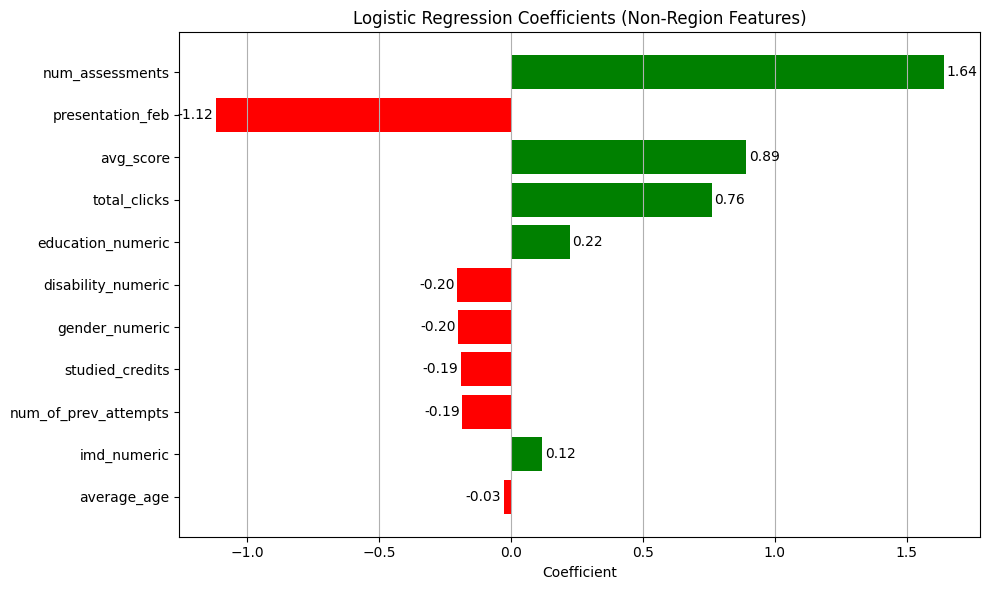

In [22]:
import matplotlib.pyplot as plt

# Filter out region columns
non_region_coefs = coef_df[~coef_df['feature'].str.startswith('region_')]

# Sort by absolute coefficient value for clarity
non_region_coefs = non_region_coefs.reindex(non_region_coefs.coefficient.abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(non_region_coefs['feature'], non_region_coefs['coefficient'], color=['green' if c > 0 else 'red' for c in non_region_coefs['coefficient']])
plt.xlabel('Coefficient')
plt.title('Logistic Regression Coefficients (Non-Region Features)')
plt.gca().invert_yaxis()  # Highest magnitude on top
plt.grid(axis='x')

# Add coefficient values next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (0.01 if width > 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', ha='left' if width > 0 else 'right')

plt.tight_layout()

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/modelling/regression_coefficients.png', bbox_inches='tight')


plt.show()


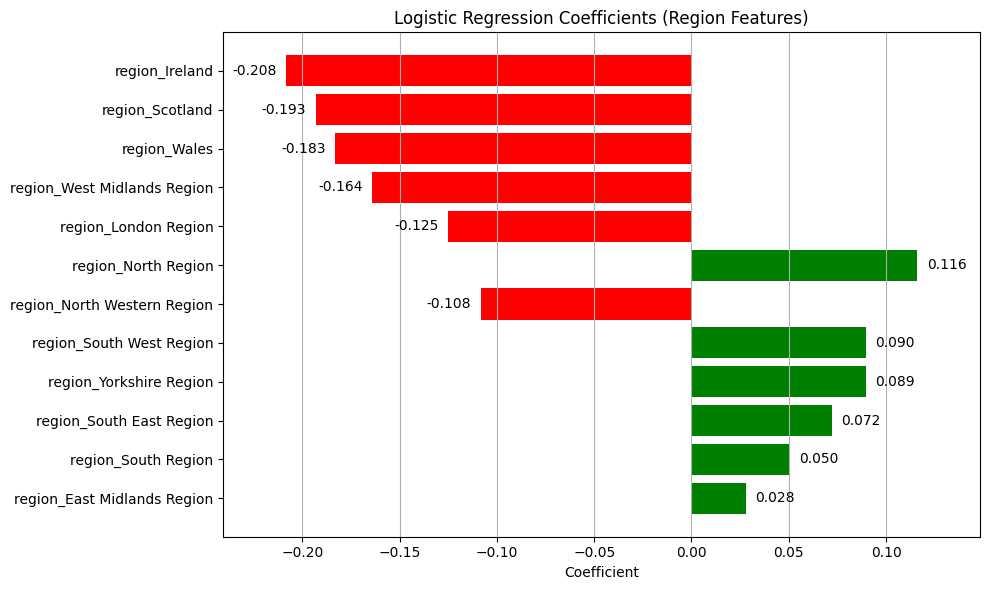

In [23]:
import matplotlib.pyplot as plt

# Filter only region features
region_coefs = coef_df[coef_df['feature'].str.startswith('region_')]

# Sort by absolute coefficient value for clarity
region_coefs = region_coefs.reindex(region_coefs.coefficient.abs().sort_values(ascending=False).index)

# Determine x-axis limits with some padding
x_min = region_coefs['coefficient'].min()
x_max = region_coefs['coefficient'].max()
x_pad = (x_max - x_min) * 0.1  # 10% padding on each side

plt.figure(figsize=(10, 6))
bars = plt.barh(region_coefs['feature'], region_coefs['coefficient'], 
                color=['green' if c > 0 else 'red' for c in region_coefs['coefficient']])
plt.xlabel('Coefficient')
plt.title('Logistic Regression Coefficients (Region Features)')
plt.gca().invert_yaxis()  # Highest magnitude on top
plt.grid(axis='x')

# Set x-axis limits with padding
plt.xlim(x_min - x_pad, x_max + x_pad)

# Add coefficient values next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (0.005 if width > 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center', ha='left' if width > 0 else 'right')

plt.tight_layout()

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/modelling/regional_regression_coefficients.png', bbox_inches='tight')
plt.show()


In [24]:
from sklearn.metrics import accuracy_score

# Predict class labels on the test set
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy on test set: {accuracy:.4f}")


Accuracy on test set: 0.8399


In [25]:
from sklearn.metrics import f1_score

# Predict class labels on the test set
y_pred = model.predict(X_test_scaled)

# Calculate F1 score
f1 = f1_score(y_test, y_pred)

print(f"F1-score on test set: {f1:.4f}")


F1-score on test set: 0.8681


ROC AUC on test set: 0.9032


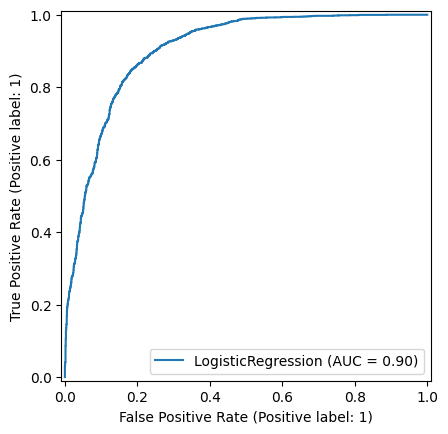

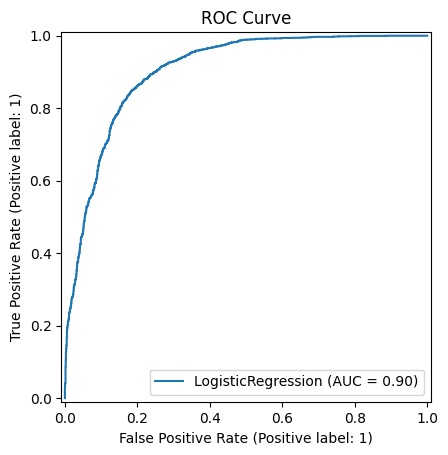

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

# Predict probabilities for the positive class (pass)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC AUC on test set: {roc_auc:.4f}")

# Plot ROC Curve
roc_display = RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
roc_display.plot()
plt.title('ROC Curve')


plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/modelling/ROC_Curve.png', bbox_inches='tight')


plt.show()


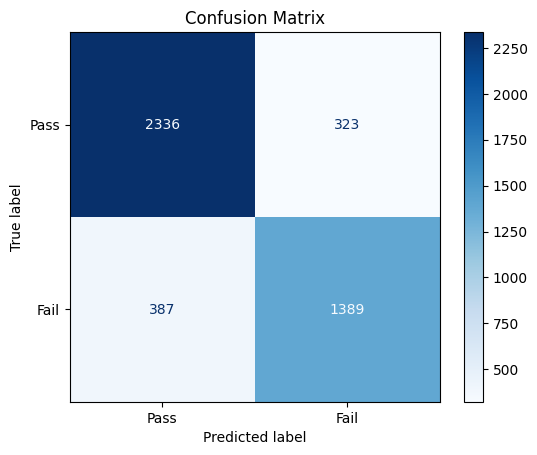

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict class labels on test set
y_pred = model.predict(X_test_scaled)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/modelling/Confusion_Matrix.png', bbox_inches='tight')


plt.show()


In [28]:
from sklearn.metrics import precision_score, recall_score

# Predict class labels on test set
y_pred = model.predict(X_test_scaled)

# Calculate precision
precision = precision_score(y_test, y_pred)
print(f"Precision on test set: {precision:.4f}")

# Calculate recall
recall = recall_score(y_test, y_pred)
print(f"Recall on test set: {recall:.4f}")


Precision on test set: 0.8579
Recall on test set: 0.8785


In [29]:
import joblib

# Save model and scaler to files
joblib.dump(model, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [30]:
import joblib

# Save scaler
scaler_file = joblib.dump(scaler, 'scaler.joblib')
print(scaler_file)  # Should print ['scaler.joblib']

# Save model
model_file = joblib.dump(model, 'model.joblib')
print(model_file)   # Should print ['model.joblib']


['scaler.joblib']
['model.joblib']


In [31]:
import joblib

ARTIFACT_DIR = "/Users/jamesjackson/dash-dashboard"  # <- put YOUR dash-dashboard path here

# These must be your already-fitted objects from training:
# scaler = StandardScaler().fit(...)
# model  = LogisticRegression(...).fit(...)

joblib.dump(scaler, f"{ARTIFACT_DIR}/scaler.joblib")
joblib.dump(model,  f"{ARTIFACT_DIR}/model.joblib")

print("Saved:", f"{ARTIFACT_DIR}/scaler.joblib", "and", f"{ARTIFACT_DIR}/model.joblib")


Saved: /Users/jamesjackson/dash-dashboard/scaler.joblib and /Users/jamesjackson/dash-dashboard/model.joblib
